#### **ML-UN(ASSIGNMENT)**

1.Given a small dataset of 2D points representing food delivery locations (e.g., [2,3], [5,8], 
[1,2], [6,9], [7,7]), plot the points on graph paper or using matplotlib, randomly pick two initial 
centroids, and manually assign each point to the nearest centroid using Euclidean distance.

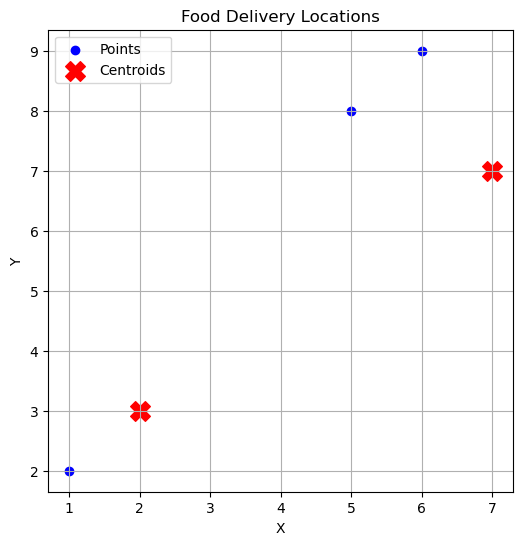

In [2]:
import matplotlib.pyplot as plt
points = [(2,3), (5,8), (1,2), (6,9), (7,7)]
centroids = [(2,3), (7,7)]

x = [p[0] for p in points]
y = [p[1] for p in points]

plt.figure(figsize=(6,6))
plt.scatter(x, y, color='blue', label='Points')

cx = [c[0] for c in centroids]
cy = [c[1] for c in centroids]

plt.scatter(cx, cy, color='red', marker='X', s=200, label='Centroids')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Food Delivery Locations")
plt.legend()
plt.grid(True)
plt.show()

2. Write a Python function assign_clusters(points, centroids) that takes a list of points and
 a list of centroids, and returns a list showing which cluster each point belongs to using Euclidean distanc.e

In [4]:
import math

def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def assign_clusters(points, centroids):
    assignments = []
    for point in points:
        distances = [euclidean(point, c) for c in centroids]
        cluster = distances.index(min(distances))
        assignments.append(cluster)
    return assignments

points = [(2,3),(5,8),(1,2),(6,9),(7,7)]
centroids = [(2,3),(7,7)]

print(assign_clusters(points, centroids))

[0, 1, 0, 1, 1]


3. Update your assign_clusters code to work with Manhattan distance as well. Allow the user
to choose between 'euclidean' and 'manhattan' as a parameter.

In [6]:
import math

def distance(p1, p2, metric='euclidean'):
    if metric == 'euclidean':
        return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)
    elif metric == 'manhattan':
        return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])
    else:
        raise ValueError("Choose 'euclidean' or 'manhattan'")

def assign_clusters(points, centroids, metric='euclidean'):
    assignments = []
    for point in points:
        distances = [distance(point, c, metric) for c in centroids]
        cluster = distances.index(min(distances))
        assignments.append(cluster)
    return assignments

points = [(2,3),(5,8),(1,2),(6,9),(7,7)]
centroids = [(2,3),(7,7)]

print("Euclidean:", assign_clusters(points, centroids, 'euclidean'))
print("Manhattan:", assign_clusters(points, centroids, 'manhattan'))

Euclidean: [0, 1, 0, 1, 1]
Manhattan: [0, 1, 0, 1, 1]


4. Implement a function update_centroids(points, assignments, k) that calculates the new centroid
 for each cluster as the mean of the assigned points. Test it with a sample dataset of your choice.

In [8]:
import numpy as np

def update_centroids(points, assignments, k):
    centroids = []
    for cluster in range(k):
        cluster_points = [points[i] for i in range(len(points))
                          if assignments[i] == cluster]
        if cluster_points:
            centroid = np.mean(cluster_points, axis=0)
            centroids.append(tuple(centroid))
        else:
            centroids.append((0,0))
    return centroids

points = [(2,3),(5,8),(1,2),(6,9),(7,7)]
assignments = [0,1,0,1,1]
k = 2
new_centroids = update_centroids(points, assignments, k)
print(new_centroids)

[(1.5, 2.5), (6.0, 8.0)]


5. Use the Elbow Method to determine the optimal number of clusters (k) for a dataset of your choice 
(e.g., favorite songs by tempo and danceability, or Zomato restaurant ratings and price). Plot the within-
cluster sum of squares for k=1 to k=6 and identify the 'elbow' point.<br><br><em><strong>Hint:</strong>
 Use sklearn's KMeans and matplotlib for plotting.</em>

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

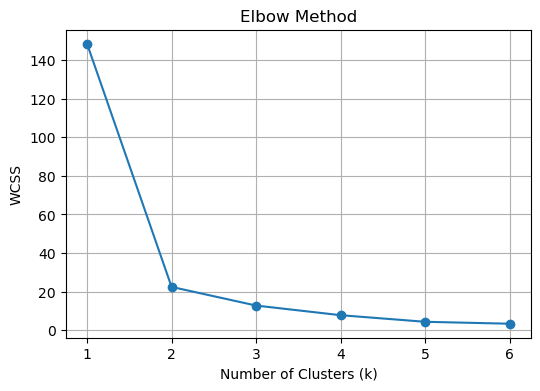

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = [
    [2,3],
    [5,8],
    [1,2],
    [6,9],
    [7,7],
    [8,6],
    [3,4],
    [2,2],
    [9,8],
    [8,9]
]

wcss = []

for k in range(1,7):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,7), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()